In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


In [ ]:
pip install openai pandas scikit-learn


In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "sk-xxxxxxxxxxxxxxxxxxxx"


In [ ]:
from openai import OpenAI
import pandas as pd
from sklearn.metrics import accuracy_score
import time
import os

# Set your API key
os.environ["OPENAI_API_KEY"] = "sk-xxxxxxxxxxxxxxxx"

client = OpenAI()

# ----------------------------
# Sample Dataset
# ----------------------------
data = [
    ("I love this product", "Positive"),
    ("This is the worst experience", "Negative"),
    ("Amazing performance!", "Positive"),
    ("I hate this service", "Negative"),
    ("Very satisfied with the quality", "Positive"),
    ("Terrible customer support", "Negative")
]

df = pd.DataFrame(data, columns=["text", "label"])

# ----------------------------
# Prompting Strategies
# ----------------------------

def zero_shot_prompt(text):
    return f"""Classify the sentiment as Positive or Negative.

Sentence: "{text}"
Answer:"""


def few_shot_prompt(text):
    return f"""Classify the sentiment as Positive or Negative.

Examples:
"I love this movie" → Positive
"I hate rain" → Negative
"This is fantastic!" → Positive

Sentence: "{text}"
Answer:"""


def cot_prompt(text):
    return f"""Classify the sentiment as Positive or Negative.
Think step by step.

Sentence: "{text}"
Answer:"""


# ----------------------------
# Model Call
# ----------------------------

def get_response(prompt):
    response = client.chat.completions.create(
        model="gpt-4o-mini",   # cheaper + faster
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content


# ----------------------------
# Evaluation
# ----------------------------

def evaluate(strategy_function):
    predictions = []
    start_time = time.time()

    for text, true_label in data:
        prompt = strategy_function(text)
        response = get_response(prompt)

        if "Positive" in response:
            predictions.append("Positive")
        else:
            predictions.append("Negative")

    accuracy = accuracy_score(df["label"], predictions)
    latency = time.time() - start_time

    return accuracy, latency


# ----------------------------
# Run
# ----------------------------

print("Evaluating Zero-Shot...")
zero_acc, zero_time = evaluate(zero_shot_prompt)

print("Evaluating Few-Shot...")
few_acc, few_time = evaluate(few_shot_prompt)

print("Evaluating Chain-of-Thought...")
cot_acc, cot_time = evaluate(cot_prompt)

# ----------------------------
# Results
# ----------------------------

results = pd.DataFrame({
    "Strategy": ["Zero-Shot", "Few-Shot", "Chain-of-Thought"],
    "Accuracy": [zero_acc, few_acc, cot_acc],
    "Latency (seconds)": [zero_time, few_time, cot_time]
})

print("\nEvaluation Results:")
print(results)


Evaluating Zero-Shot...


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-xxxxx*******xxxx. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [ ]:
!pip install transformers torch scikit-learn

from transformers import pipeline
from sklearn.metrics import accuracy_score
import time
import pandas as pd

# Load pretrained sentiment model
classifier = pipeline("sentiment-analysis")

# Dataset
data = [
    ("I love this product", "POSITIVE"),
    ("This is the worst experience", "NEGATIVE"),
    ("Amazing performance!", "POSITIVE"),
    ("I hate this service", "NEGATIVE"),
    ("Very satisfied with the quality", "POSITIVE"),
    ("Terrible customer support", "NEGATIVE")
]

df = pd.DataFrame(data, columns=["text", "label"])

# Evaluation
predictions = []
start_time = time.time()

for text, true_label in data:
    result = classifier(text)[0]['label']
    predictions.append(result)

accuracy = accuracy_score(df["label"], predictions)
latency = time.time() - start_time

print("Accuracy:", accuracy)
print("Latency:", latency)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Accuracy: 1.0
Latency: 0.33617115020751953


In [ ]:
!pip install transformers torch scikit-learn

from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import time

# Load pretrained sentiment model
classifier = pipeline("sentiment-analysis")

# Dataset
data = [
    ("I love this product", "POSITIVE"),
    ("This is the worst experience", "NEGATIVE"),
    ("Amazing performance!", "POSITIVE"),
    ("I hate this service", "NEGATIVE"),
    ("Very satisfied with the quality", "POSITIVE"),
    ("Terrible customer support", "NEGATIVE")
]

df = pd.DataFrame(data, columns=["text", "label"])

# ----------------------------
# Prediction
# ----------------------------

predictions = []
start_time = time.time()

for text, true_label in data:
    result = classifier(text)[0]['label']
    predictions.append(result)

latency = time.time() - start_time

# ----------------------------
# Metrics
# ----------------------------

accuracy = accuracy_score(df["label"], predictions)
precision = precision_score(df["label"], predictions, pos_label="POSITIVE")
recall = recall_score(df["label"], predictions, pos_label="POSITIVE")
f1 = f1_score(df["label"], predictions, pos_label="POSITIVE")

# ----------------------------
# Output
# ----------------------------

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("\nDetailed Report:\n")
print(classification_report(df["label"], predictions))
print("Latency (seconds):", latency)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Detailed Report:

              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00         3
    POSITIVE       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

Latency (seconds): 0.3066849708557129


In [ ]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import time

# Load zero-shot classifier model
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

# Dataset
data = [
    ("I love this product", "Positive"),
    ("This is the worst experience", "Negative"),
    ("Amazing performance!", "Positive"),
    ("I hate this service", "Negative"),
    ("Very satisfied with the quality", "Positive"),
    ("Terrible customer support", "Negative")
]

df = pd.DataFrame(data, columns=["text", "label"])

labels = ["Positive", "Negative"]

# ----------------------------
# ZERO-SHOT FUNCTION
# ----------------------------

def evaluate_zero_shot():
    predictions = []
    start = time.time()

    for text, true_label in data:
        result = classifier(text, labels)
        predictions.append(result["labels"][0])

    latency = time.time() - start

    acc = accuracy_score(df["label"], predictions)
    prec = precision_score(df["label"], predictions, pos_label="Positive")
    rec = recall_score(df["label"], predictions, pos_label="Positive")
    f1 = f1_score(df["label"], predictions, pos_label="Positive")

    return acc, prec, rec, f1, latency


# ----------------------------
# FEW-SHOT FUNCTION
# ----------------------------

def evaluate_few_shot():
    predictions = []
    start = time.time()

    # Few-shot examples added manually
    few_shot_context = """
    Example 1: I love this movie → Positive
    Example 2: I hate rain → Negative
    Example 3: This is amazing → Positive
    """

    for text, true_label in data:
        prompt = few_shot_context + "\nSentence: " + text
        result = classifier(prompt, labels)
        predictions.append(result["labels"][0])

    latency = time.time() - start

    acc = accuracy_score(df["label"], predictions)
    prec = precision_score(df["label"], predictions, pos_label="Positive")
    rec = recall_score(df["label"], predictions, pos_label="Positive")
    f1 = f1_score(df["label"], predictions, pos_label="Positive")

    return acc, prec, rec, f1, latency


# ----------------------------
# RUN EVALUATION
# ----------------------------

print("Evaluating Zero-Shot...")
z_acc, z_prec, z_rec, z_f1, z_time = evaluate_zero_shot()

print("Evaluating Few-Shot...")
f_acc, f_prec, f_rec, f_f1, f_time = evaluate_few_shot()

# ----------------------------
# RESULTS TABLE
# ----------------------------

results = pd.DataFrame({
    "Strategy": ["Zero-Shot", "Few-Shot"],
    "Accuracy": [z_acc, f_acc],
    "Precision": [z_prec, f_prec],
    "Recall": [z_rec, f_rec],
    "F1 Score": [z_f1, f_f1],
    "Latency (sec)": [z_time, f_time]
})

print("\nComparison Results:\n")
print(results)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Evaluating Zero-Shot...
Evaluating Few-Shot...

Comparison Results:

    Strategy  Accuracy  Precision  Recall  F1 Score  Latency (sec)
0  Zero-Shot       1.0        1.0     1.0  1.000000       8.105310
1   Few-Shot       0.5        0.5     1.0  0.666667      22.622919


<Figure size 640x480 with 0 Axes>

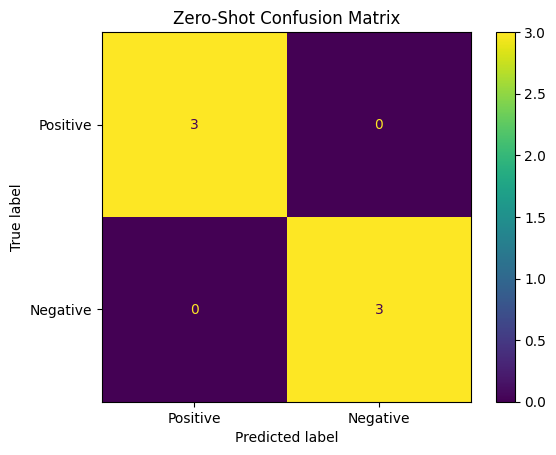

<Figure size 640x480 with 0 Axes>

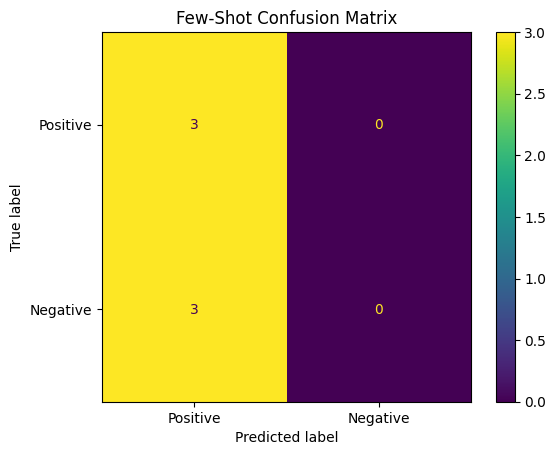

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["Positive", "Negative"]

# ----------------------------
# ZERO-SHOT CONFUSION MATRIX
# ----------------------------

zero_predictions = []
for text, true_label in data:
    result = classifier(text, labels)
    zero_predictions.append(result["labels"][0])

cm_zero = confusion_matrix(df["label"], zero_predictions, labels=labels)

plt.figure()
disp_zero = ConfusionMatrixDisplay(confusion_matrix=cm_zero,
                                   display_labels=labels)
disp_zero.plot()
plt.title("Zero-Shot Confusion Matrix")
plt.show()


# ----------------------------
# FEW-SHOT CONFUSION MATRIX
# ----------------------------

few_predictions = []

few_shot_context = """
Example 1: I love this movie → Positive
Example 2: I hate rain → Negative
Example 3: This is amazing → Positive
"""

for text, true_label in data:
    prompt = few_shot_context + "\nSentence: " + text
    result = classifier(prompt, labels)
    few_predictions.append(result["labels"][0])

cm_few = confusion_matrix(df["label"], few_predictions, labels=labels)

plt.figure()
disp_few = ConfusionMatrixDisplay(confusion_matrix=cm_few,
                                  display_labels=labels)
disp_few.plot()
plt.title("Few-Shot Confusion Matrix")
plt.show()
